In [5]:
using LinearAlgebra
using BSplineKit
using Plots
using DelimitedFiles

In [ ]:
N = 199
θ = range(0,length=N+1,stop=pi)
x = reshape(-cos.(θ), N+1, 1)
c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
X = repeat(x, 1, N+1);
dX = X - X';
D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
D = D - diagm(vec(sum(D, dims=2))); 
z = 200 .* x .+ 500  
D = 1/200 .* D

200×200 Matrix{Float64}:
 -66.0025       80.2501      -20.0638      …   -0.00500031   0.0025
 -20.0625       10.0306       13.3761           0.00250031  -0.00125008
   5.01594     -13.3761        2.50735         -0.00250078   0.00125031
  -2.22954       5.01657      -8.02701          0.00250156  -0.0012507
   1.2543       -2.67589       3.34507         -0.00250265   0.00125125
  -0.802901      1.67274      -1.91183     …    0.00250405  -0.00125195
   0.557697     -1.14729       1.25492         -0.00250577   0.00125281
  -0.409848      0.836789     -0.892631         0.0025078   -0.00125382
   0.313887     -0.637753      0.669682        -0.00251015   0.001255
  -0.248097      0.502408     -0.522014         0.00251282  -0.00125633
   ⋮                                       ⋱                
  -0.001255      0.00251015   -0.00251062       0.637753    -0.313887
   0.00125382   -0.0025078     0.00250828      -0.836789     0.409848
  -0.00125281    0.00250577   -0.00250624       1.14729     -

In [168]:
data_crit = [0 0 0 0]
for OMEGA = (0.0,4.0,8.0)
    for Tw = 0.8 : 0.2 : 1.2
        for Ma = 0.3 : 0.3 : 1.2
            data1 = readdlm("Cr_$(OMEGA)_30_$(Ma)_$(Tw).dat")
            inter_ai = BSplineKit.interpolate(data1[:,2],data1[:,7],BSplineOrder(4),Natural())
            r_range = range(data1[1,2],data1[end,2],1001)
            data_int = inter_ai.(z)
            d1 = D * data_int
            R_crit = z[findmax(d1)[2],1]
            data_crit = [data_crit; [OMEGA Tw Ma R_crit]]
        end
    end
end
writedlm("critical_data_d1.dat",data_crit) 
# plot(z,d1)

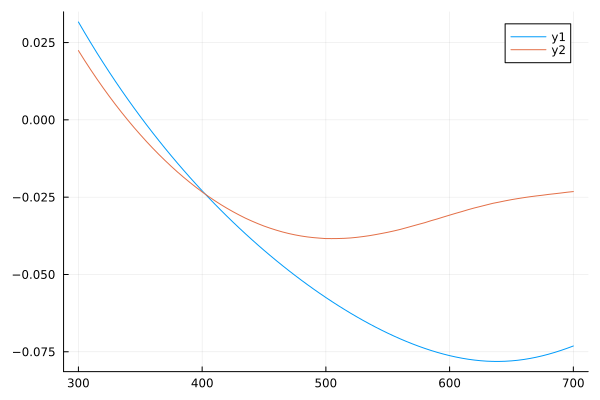

In [212]:
OMEGA = 4.0
Ma = 0.3
Tw = 0.8
data1 = readdlm("Cr_$(OMEGA)_30_$(Ma)_$(Tw).dat")
inter_ai = BSplineKit.interpolate(data1[:,2],data1[:,7],BSplineOrder(4),Natural())
r_range = range(data1[1,2],data1[end,2],1001)
data_int = inter_ai.(z)
d1 = D * data_int
d2 = D * d1
R_crit = z[findmax(d1)[2],1]
# plot(z,d1)
plot!(data1[:,2],data1[:,7])
# data_crit = [data_crit; [OMEGA Tw Ma R_crit]]
# data = [data1[:,2] data1[:,7] data]

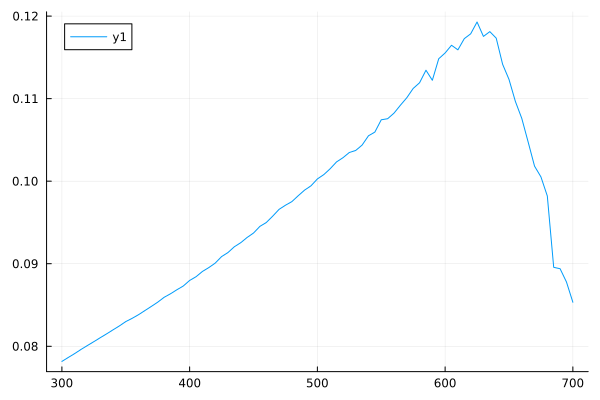

In [213]:
plot(data1[:,2],data1[:,3])

In [182]:
z[findmax(d1)[2],1]

470.1172128191478

In [3]:
# =========================================================================
#  10阶中心差分导数求解器（带边界连续降阶功能）
#  适用场景：流体力学稳定性理论分析（高精度，低耗散）
# =========================================================================

using LinearAlgebra

"""
    fd_weights(grid_points, z, k)

计算有限差分系数的辅助函数。
输入：
- grid_points: 模板点的相对坐标数组 (例如 [-1, 0, 1])
- z: 求导点在相对坐标系中的位置 (通常为 0)
- k: 导数阶数 (1=一阶导, 2=二阶导)
输出：
- weights: 对应的差分系数向量
"""
function fd_weights(grid_points, z, k)
    n = length(grid_points)
    # 构建范德蒙德矩阵的转置 (Vandermonde system)
    # A * w = b
    # A_ij = (x_j)^i / i!
    # b_i = 1 if i == k, else 0
    
    A = zeros(Float64, n, n)
    b = zeros(Float64, n)
    
    for row in 1:n
        power = row - 1
        for col in 1:n
            A[row, col] = (grid_points[col] - z)^power / factorial(power)
        end
    end
    
    if k < n
        b[k+1] = 1.0
    end
    
    return A \ b
end

"""
    diff_10th_order(u, dx)

输入：
- u: 等间距网格上的函数值数组 (Vector)
- dx: 网格间距 (Float64)

输出：
- du: 一阶导数数组
- d2u: 二阶导数数组
"""
function diff_10th_order(u::Vector{T}, dx::T) where T <: AbstractFloat
    N = length(u)
    du = zeros(T, N)
    d2u = zeros(T, N)
    
    # === 1. 预计算所有需要的差分系数 ===
    # 键是(半径, 导数阶数)，值是系数向量
    # 半径 r 对应模板宽度 2r+1
    coeffs = Dict{Tuple{Int, Int}, Vector{Float64}}()
    
    # 中心差分系数 (r=1 到 r=5, 对应 2阶 到 10阶)
    for r in 1:5
        stencil = Float64.(collect(-r:r))
        coeffs[(r, 1)] = fd_weights(stencil, 0.0, 1)
        coeffs[(r, 2)] = fd_weights(stencil, 0.0, 2)
    end
    
    # 边界偏心差分系数 (使用3点，2阶精度)
    # 左边界 (求导点在索引1，模板为 1,2,3 -> 相对坐标 0,1,2)
    coeffs[(0, 1)] = fd_weights([0.0, 1.0, 2.0], 0.0, 1) # 左边界一阶
    coeffs[(0, 2)] = fd_weights([0.0, 1.0, 2.0], 0.0, 2) # 左边界二阶
    
    # === 2. 逐点计算导数 ===
    @inbounds for i in 1:N
        # 计算当前点左右可用的最大对称邻居数
        dist_left = i - 1
        dist_right = N - i
        radius = min(dist_left, dist_right)
        
        # 限制最大半径为5 (10阶精度)
        if radius > 5
            radius = 5
        end
        
        if radius == 0
            # --- 物理边界处理 (i=1 或 i=N) ---
            if i == 1
                # 左边界：使用前3点
                w1 = coeffs[(0, 1)]
                w2 = coeffs[(0, 2)]
                subset = u[1:3]
                
                du[i] = dot(w1, subset) / dx
                d2u[i] = dot(w2, subset) / dx^2
            else
                # 右边界：使用后3点 (利用对称性或重新计算，这里直接镜像处理)
                # 相当于对倒序的最后3点求负导数(一阶)或正导数(二阶)
                # 为清晰起见，显式计算右边界权重
                w1_r = fd_weights([-2.0, -1.0, 0.0], 0.0, 1)
                w2_r = fd_weights([-2.0, -1.0, 0.0], 0.0, 2)
                subset = u[end-2:end]
                
                du[i] = dot(w1_r, subset) / dx
                d2u[i] = dot(w2_r, subset) / dx^2
            end
            
        else
            # --- 内部点处理 (中心差分降阶) ---
            # radius=5 -> 10阶
            # radius=4 -> 8阶
            # ...
            # radius=1 -> 2阶
            
            w1 = coeffs[(radius, 1)]
            w2 = coeffs[(radius, 2)]
            
            # 获取对应的 stencil 数据
            subset = u[i-radius : i+radius]
            
            du[i] = dot(w1, subset) / dx
            d2u[i] = dot(w2, subset) / dx^2
        end
    end
    
    return du, d2u
end

# =========================================================================
#  验证测试模块
# =========================================================================

# 构造一个光滑函数进行测试：f(x) = sin(2x) * exp(-0.1x)
# 这类函数常见于稳定性分析的模态波形
x_min, x_max = 0.0, 10.0
N_grid = 101
dx = (x_max - x_min) / (N_grid - 1)
x = range(x_min, x_max, length=N_grid) |> collect

# 定义原函数及其解析导数
f(x) = sin(2x) * exp(-0.1x)
df_exact(x) = 2cos(2x)*exp(-0.1x) - 0.1sin(2x)*exp(-0.1x)
d2f_exact(x) = -4sin(2x)*exp(-0.1x) - 0.4cos(2x)*exp(-0.1x) + 0.01sin(2x)*exp(-0.1x)

u = f.(x)

# 运行差分程序
du_num, d2u_num = diff_10th_order(u, dx)


([2.025314046032901, 1.9085367124612755, 1.7673913926820244, 1.5470905283144711, 1.2698540789559936, 0.9478597068718397, 0.594735227775169, 0.2250699034729603, -0.14618138588720936, -0.5042971313067812  …  0.6654483065443861, 0.735162783192293, 0.7744070407454342, 0.7822315673307789, 0.7589489052957787, 0.7060962916661645, 0.6263503752028416, 0.523378116500805, 0.39952636516675827, 0.27070550890066575], [-1.1677733357162543, -1.1677733357162543, -1.8840963541021352, -2.506716447747495, -3.0177757198212096, -3.3993041034087965, -3.63877007939354, -3.7295112053261636, -3.6708818796572706, -3.4681597491578584  …  0.8431843873463886, 0.5474299700928489, 0.23587053400347088, -0.07885281278681983, -0.3842240795418224, -0.6683451618455715, -0.9203942678914679, -1.1310102656072702, -1.288208562660925, -1.288208562660925])